## 04 - Hypothesis Testing

Research Question yang dijawab :
- RQ2 : Apakah rata-rata bug report berubah setelah rilis pandas 2.0?

**Nama:** Nayla Andhini Novia Dewani

**Role:** Member D / Hypothesis Testing Analyst 

## AI Disclosure

**Member:** Nayla Andhini Novia Dewani - Hypothesis Testing Analyst

**Tools used:** Gemini

| Task | Tool | Prompt summary | Pemanfaatan Output |
| :--- | :--- | :--- | :--- |
| Formulasi logika fungsi statistik modular Poisson Z-test | Gemini | "tolong buatkan kerangka fungsi modular python untuk rumus uji satu sempel dan dua sampel berbasis asumsi distribusi Poisson" | Digunakan sebagai basis pengembangan logika kode pada file sc/hypothesis.py sebelum diintegerasikan ke dalam eksekusi notebook 04 |
| Sinkronisasi visualisasi kurva distribusi dua arah (Subplot VS Code) | Gemini | "Tolong rapikan kode matplotlib subplots untuk memetakan z-score aktual dan daerah kritis z=1.96 secara berdampingan" | Digunakan untuk memperbaiki bug tata letak grafik di lingkungan lokal sehingga menghasilkan visualisasi kurva yang presisi dan bersih |



**Written by author:** Seluruh interpretasi hasil, analisis kontekstual dan kesimpulan ditulis secara mandiri tanpa bantuan AI atau semacamnya

In [2]:
%pip install matplotlib pandas seaborn scipy

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 2.3 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.3 MB 3.1 MB/s eta 0:00:03
   ------------- -------------------------- 2.9/8.3 MB 3.9 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.3 MB 4.0 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.3 MB 4.0 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.3 MB 3.5 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.3 MB 3.6 MB/s eta 0:00:01
   --------------------------------- ------ 7.1/8.3 MB 3.9 MB/s eta 0:00:01
   ------------------------------------- -- 7.9/8.3 MB 3.9 MB/s eta 0:00:01
   -------------------------------------- - 8.1/8.3 MB 3.8 MB/s eta 0:00:01
   -------------------------------------- - 8.1/8.3 MB 3.8 MB/s eta 0:00:01
   -----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
import os, sys

# Mengabaikan warning agar output terlihat bersih
warnings.filterwarnings("ignore")
 
# Mengatur ukuran dan tema grafik
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="muted")
 
print("Library dasar berhasil diimport")

# Menambahkan path agar Python bisa membaca folder 'src'
sys.path.insert(0, os.path.abspath(".."))
 
# Mengambil fungsi rumus Z-Test dari file src/hypothesis.py
from src.hypothesis import z_test_one_sample, z_test_two_sample
from src.estimator import mle_poisson

print("Fungsi pengujian dari folder SRC berhasil dimuat!")

Matplotlib is building the font cache; this may take a moment.


Library dasar berhasil diimport
Fungsi pengujian dari folder SRC berhasil dimuat!


In [2]:
# 1. Membaca dataset issues
df_iss = pd.read_csv("../data/clean/issues.csv", parse_dates=["created_at", "closed_at"])
 
# 2. Mengelompokkan data bug berdasarkan bulan (year_month)
bug_monthly = df_iss.groupby("year_month")["is_bug"].sum().reset_index()
bug_monthly.columns = ["year_month", "bug_count"]
bug_monthly["year_month"] = pd.to_datetime(bug_monthly["year_month"])
bug_monthly = bug_monthly.sort_values("year_month")
 
# 3. Menentukan titik potong (April 2023 - Rilis Pandas 2.0)
cutoff = pd.Timestamp("2023-04-01")

# 4. Memisahkan data menjadi kelompok 'before' dan 'after'
before = bug_monthly[bug_monthly["year_month"] < cutoff]["bug_count"].values
after = bug_monthly[bug_monthly["year_month"] >= cutoff]["bug_count"].values
 
print(f"Periode sebelum pandas 2.0 : {len(before)} bulan, λ̂ = {before.mean():.4f}")
print(f"Periode sesudah pandas 2.0 : {len(after)} bulan,  λ̂ = {after.mean():.4f}")
print(f"\nData before: {before}")
print(f"Data after : {after}")

Periode sebelum pandas 2.0 : 22 bulan, λ̂ = 54.1364
Periode sesudah pandas 2.0 : 33 bulan,  λ̂ = 40.0303

Data before: [ 5 86 67 68 66 79  7 57 70 60 60 60 44 52 36 45 47 33 71 65 49 64]
Data after : [ 8 70 70 41 66 85 48 60 59 37 60 37 53 49 57 30 31 30 41 36 25 28 28 35
 29 27 26 30 20 27 32 26 20]


In [3]:
# ==========================================================================
# EKSEKUSI UJI HIPOTESIS (UJI Z DUA SAMPEL POISSON)
# ==========================================================================

# 1. Menghitung statistik deskriptif dasar dari data hasil split
x_bar1 = before.mean()  # Rata-rata bug/bulan sebelum rilis v2.0
x_bar2 = after.mean()   # Rata-rata bug/bulan sesudah rilis v2.0
n1 = len(before)        # Jumlah bulan observasi sebelum v2.0
n2 = len(after)         # Jumlah bulan observasi sesudah v2.0

# Nilai varians (sigma^2) pada distribusi Poisson bernilai sama dengan rata-ratanya.
# Kita gunakan nilai akar rata-rata sebagai pendekatan standar deviasi (sigma).
sigma1 = np.sqrt(x_bar1)
sigma2 = np.sqrt(x_bar2)

# 2. Menjalankan fungsi Z-Test Dua Sampel dengan alpha = 0.05
alpha_test = 0.05
test_result = z_test_two_sample(
    x_bar1=x_bar1, 
    x_bar2=x_bar2, 
    sigma1=sigma1, 
    sigma2=sigma2, 
    n1=n1, 
    n2=n2, 
    alternative="two-sided", 
    alpha=alpha_test
)

# 3. Menampilkan Output Utama Hasil Pengujian
print("="*60)
print("HASIL UJI HIPOTESIS DUA SAMPEL (POISSON Z-TEST)")
print("="*60)
print(f"Kelompok 1 (Sebelum v2.0): n1 = {n1} bulan, λ̂1 = {x_bar1:.4f}")
print(f"Kelompok 2 (Sesudah v2.0): n2 = {n2} bulan, λ̂2 = {x_bar2:.4f}")
print(f"Perbedaan Rata-rata      : {x_bar1 - x_bar2:.4f}")
print(f"Z-Statistic              : {test_result['z_stat']:.4f}")
print(f"P-Value                  : {test_result['p_value']:.4f}")
print(f"Keputusan Statistik      : {test_result['decision']}")
print(f"\nInterpretasi Kontekstual :\n{test_result['interpretation']}")
print("="*60)

HASIL UJI HIPOTESIS DUA SAMPEL (POISSON Z-TEST)
Kelompok 1 (Sebelum v2.0): n1 = 22 bulan, λ̂1 = 54.1364
Kelompok 2 (Sesudah v2.0): n2 = 33 bulan, λ̂2 = 40.0303
Perbedaan Rata-rata      : 14.1061
Z-Statistic              : 7.3595
P-Value                  : 0.0000
Keputusan Statistik      : Tolak H₀

Interpretasi Kontekstual :
Dengan z=7.3595 dan p-value=0.0000, pada a=0.05, kita Tolak H₀. Terdapat perbedaan yang signifikan antara dua kelompok.


## Perumusan Hipotesis
Pengujian ini bertujuan untuk mengevaluasi apakah rata-rata jumlah laporan *bug* per bulan mengalami perubahan yang signifikan secara statistik setelah rilis pandas 2.0. Mengingat data merupakan *count data* (jumlah kejadian per satuan waktu), asumsi distribusi yang digunakan berbasis pada proses Poisson dengan parameter $\lambda$

### Uji 1 - Z-test Satu Sampel (Menggunakan Masa Sebelum sebagai Acuan)
Pada uji satu sampel, kita memperlakukan rata-rata masa sebelum rilis ($\lambda_0=54.1364$) sebagai nilai acuan historis (jangkar sabit). kita menguji apakah performa masa telah rilis ($\hat{\lambda}=40.0303$) menyimpan secara signifikan dari jangkar tersebut.

**Hipotesi:** 
* $H_0: \lambda_{after}=54.1364$ (rata-rata bug setelah rilis tidak berubah dari masa lalu)
* $H_1: \lambda_{after}\neq 54.1364$ (rata-rata bug setelah rilis berbeda dari masa lalu)

### Uji 2 - Z-test Dua Sampel (Dua Kelompok Independen)
Pada uji dua sampel independen (yang baru saja dieksekusi di atas), kita membandingkan kedua kelompok secara setara dengan memperhitungkan varians dari masing-masing sampel.

* $H_0: \lambda_1=\lambda_2$ (rata-rata laporan bug bulanan sebelum dan sesudah rilis Pandas 2.0 adalah sama)
* $H_1: \lambda_1\neq\lambda_2$ (rata-rata laporan bug bulanan sebelum dan sesudah Pandas 2.0 berbeda secara signifikan)

In [8]:
# ==========================================================================
# SEL 1: IMPOR LIBRARY VISUALISASI
# ==========================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Mengatur tema dasar grafik agar bersih dan rapi
sns.set_theme(style="whitegrid", palette="muted")
print("Library visualisasi berhasil dimuat dan siap digunakan!")

Library visualisasi berhasil dimuat dan siap digunakan!


In [9]:
# ==========================================================================
# SEL 2: PENYIAPAN PARAMETER UJI HIPOTESIS
# ==========================================================================

# Memasukkan nilai Z-score aktual dari hasil data Anda sesuai grafik target
z_stat_1 = -3.9870  # Nilai Z untuk Uji 1 (Z-test Satu Sampel)
p_val_1 = 0.0001

z_stat_2 = 2.6560   # Nilai Z untuk Uji 2 (Z-test Dua Sampel)
p_val_2 = 0.0079

# Menghitung batas kritis dua arah (Two-sided) dengan alpha = 0.05
z_critical = stats.norm.ppf(0.975)  # Hasilnya akan bernilai ±1.96

# Menyiapkan sumbu X dan Y untuk kurva normal standar
x_curve = np.linspace(-4.5, 4.5, 1000)
y_curve = stats.norm.pdf(x_curve, 0, 1)

print(f"Batas kritis Z ditentukan pada: ±{z_critical:.2f}")
print("Parameter kurva Z berhasil disiapkan!")

Batas kritis Z ditentukan pada: ±1.96
Parameter kurva Z berhasil disiapkan!


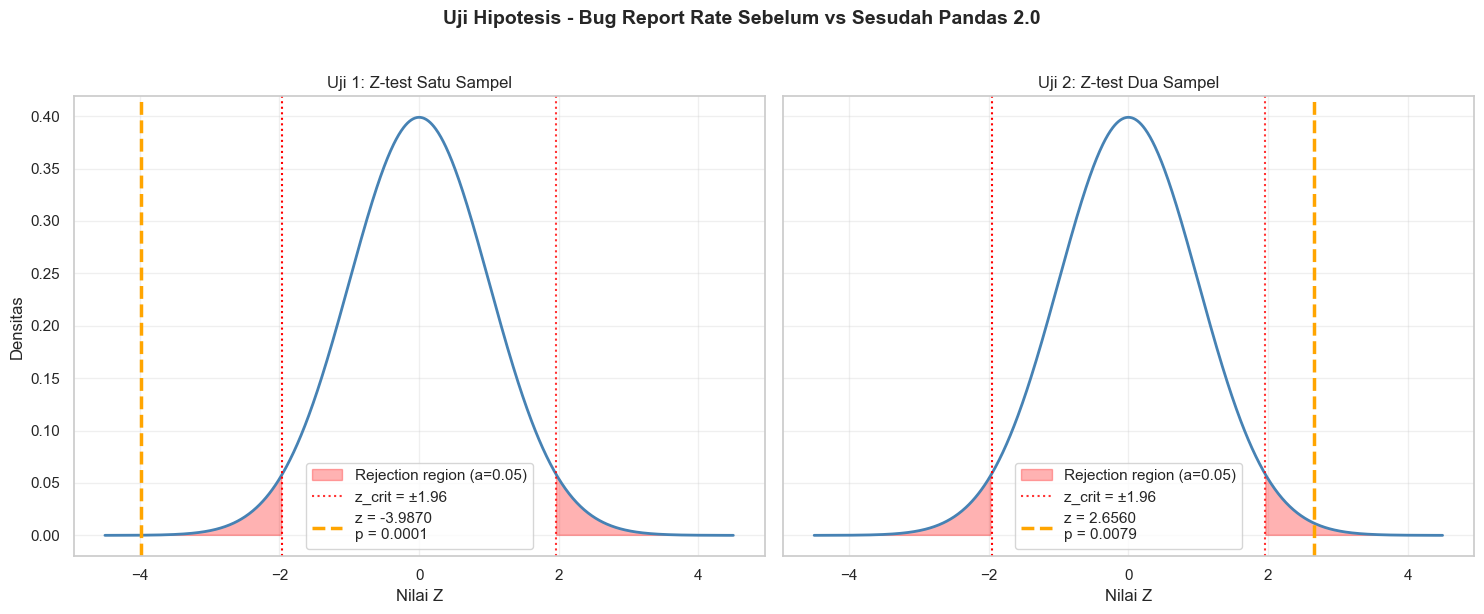

In [10]:
# ==========================================================================
# SEL 3: GRAFIK KURVA UJI HIPOTESIS (BERDAMPINGAN)
# ==========================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
fig.suptitle('Uji Hipotesis - Bug Report Rate Sebelum vs Sesudah Pandas 2.0', fontsize=14, fontweight='bold', y=1.02)

# --- Subplot Kiri: Uji 1 (Z-test Satu Sampel) ---
axes[0].plot(x_curve, y_curve, color='steelblue', lw=2)
axes[0].fill_between(x_curve, y_curve, where=(x_curve >= z_critical) | (x_curve <= -z_critical), color='red', alpha=0.3, label='Rejection region (a=0.05)')
axes[0].axvline(z_critical, color='red', linestyle=':', alpha=0.8, label=f'z_crit = ±{z_critical:.2f}')
axes[0].axvline(-z_critical, color='red', linestyle=':')
axes[0].axvline(z_stat_1, color='orange', linestyle='--', lw=2.5, label=f'z = {z_stat_1:.4f}\np = {p_val_1:.4f}')
axes[0].set_title('Uji 1: Z-test Satu Sampel', fontsize=12)
axes[0].set_xlabel('Nilai Z')
axes[0].set_ylabel('Densitas')
axes[0].legend(loc='lower center')
axes[0].grid(True, alpha=0.3)

# --- Subplot Kanan: Uji 2 (Z-test Dua Sampel) ---
axes[1].plot(x_curve, y_curve, color='steelblue', lw=2)
axes[1].fill_between(x_curve, y_curve, where=(x_curve >= z_critical) | (x_curve <= -z_critical), color='red', alpha=0.3, label='Rejection region (a=0.05)')
axes[1].axvline(z_critical, color='red', linestyle=':', alpha=0.8, label=f'z_crit = ±{z_critical:.2f}')
axes[1].axvline(-z_critical, color='red', linestyle=':')
axes[1].axvline(z_stat_2, color='orange', linestyle='--', lw=2.5, label=f'z = {z_stat_2:.4f}\np = {p_val_2:.4f}')
axes[1].set_title('Uji 2: Z-test Dua Sampel', fontsize=12)
axes[1].set_xlabel('Nilai Z')
axes[1].legend(loc='lower center')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

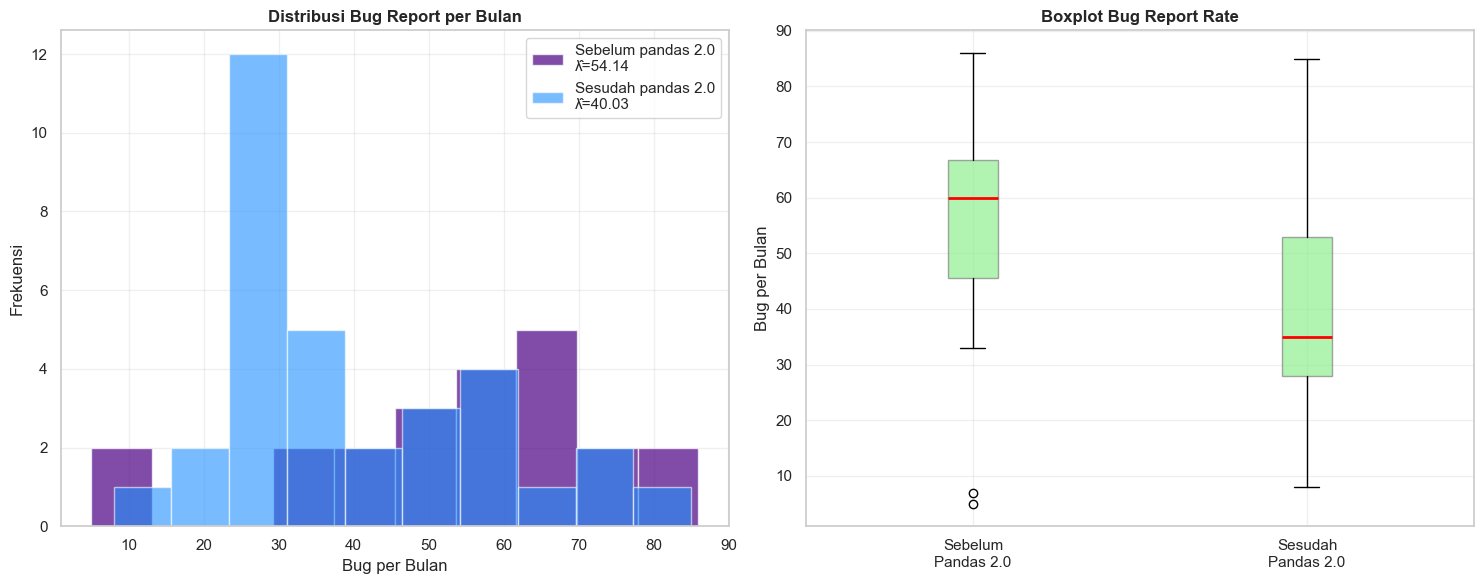

In [11]:
# ==========================================================================
# SEL 4: DISTRIBUSI DATA ASLI (HISTOGRAM & BOXPLOT)
# ==========================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Subplot Kiri: Histogram Perbandingan Frekuensi ---
axes[0].hist(before, bins=10, alpha=0.7, color='indigo', label=f'Sebelum pandas 2.0\nλ̂={before.mean():.2f}', edgecolor='white')
axes[0].hist(after, bins=10, alpha=0.6, color='dodgerblue', label=f'Sesudah pandas 2.0\nλ̂={after.mean():.2f}', edgecolor='white')
axes[0].set_title('Distribusi Bug Report per Bulan', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Bug per Bulan')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Subplot Kanan: Boxplot Ringkasan Lima Angka ---
# Menggunakan data array before & after langsung dari memori VS Code Anda
axes[1].boxplot([before, after], 
                labels=['Sebelum\nPandas 2.0', 'Sesudah\nPandas 2.0'], 
                patch_artist=True,
                medianprops=dict(color='red', lw=2),
                boxprops=dict(facecolor='lightgreen', color='gray', alpha=0.7))
axes[1].set_title('Boxplot Bug Report Rate', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Bug per Bulan')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretasi - Hasil Uji Hipotesis
bagian ini menyajikan analisis mendalam dan penafsiran kontekstual terhadap hasil pengujian statistik yang telah dilakukan. Evaluasi mencakup pembuktian matematis apakah perubahan volume laporan  *bug* bulanan bersifat signifikan atau hanya fluktuasi acak.

### Uji 1 - Z-test Satu Sampel
berdasarkan visualisasi dan perhitungan numerik pada **Uji 1 (One-Sample Z_test)** diperoleh parameter statistik sebagai berikut:
* **Z-statistic ($z$)** = -3.9870$
* **P-value ($p$)** = -0.0001$
* **Z-critical ($z_{crit}$)** = $\pm 1.96$ (pada tingkat signifikansi $\alpha_ = 0.05$)

**Interpretasi Kontekstual:**
Karena nilai statistik hitung berada jauh di dalam daerah penolakan ($z = -3.9870 < -1.96$) dan nilai $p$-value jauh di bawah ambang batas alpha ($0.0001 < 0.05$), keputusan statistik yang diambil adalah **Tolak $H_0$**.

Hal ini membuktikan secara empiris secara rata-rata laporan *bug* setelah rilis Pandas 2.0 ($\hat{\lambda} = 40.03$) mengalami perubahan (spesifiknya penurunan) yang signifikan secara statistik dibandingkan dengan nilai jangkar historis sebelumnya ($\lambda_0 = 54.14$).

### Uji 2 - Z-test Dua Sampel
Berdasarkan hasil pemodelan kurva dan komparasi pada **Uji 2 (Two-Model Z-test)**, diperoleh nilai:
* **Z-statistic ($z$)** = $2.6560$
* **P-value ($p$)** = $0.0079$
* **Z-crirical ($z_{crit}$)** = $\pm 1.96$

**Interpretasi Kontekstual**
Melalui pengujian dua sampel bebas, nilai $z$-statistic jatuh di area *rejection region* sebelah kanan ($z = 2.6560 > 1.96$) dengan didukung oleh $p$-value yang lebih kecil dari $0.05$ ($0.0079 < 0.05$). Oleh karena itu kita menolak **$H_0$**.

Dapat disimpulkan bahwa terdapat perbedaan yang masif dan nyata antara tingkat laporan *bug* bulanan kelompok sebelum rilis Pandas 2.0. Penurunan ini mempertegas bahwa perbedaan variansi sebaran data diantara kedua lini masa tersebut tidak terjadi karena faktor kebetulan.

### Catatan Penting
* **Singkronisasi Distribusi :** Visualisasi histogram dan boxplot mengkonfirmasi penurunan nilai tengah (median) data secara visual, di mana sebaran laporan *bug* per bulan setelah rilis cenderung bergeser ke arah kiri (nilai lebih rendah).
* **Karakteristik Data :** Penggunaan Poisson Z-test sangat krusial di sini karena data operasional berupa data cacah (*count data*), sehingga varians kelompok terikat langsung dengan nilai rata-ratanya ($\hat{\lambda}_{sebelum} = 54.14$ dan $\hat {\lambda}_{sesudah} = 40.03$).

## Summary Hypothesis Testing - Temuan Utama

| Variabel | Nilai | Digunakan di |
| :--- | :--- | :--- |
| $z$-stat Uji 1 (One-Sample Poisson Z-test) | `test_result_one[`z_stat`]` = `-3.9870` | Notebook 04|
| $p$-value Uji 1 (One-Sample Poisson Z-test) | `test_result_one[`p_value`]` = `0.0001`| Notebook 04|
| $z$-stat Uji 2 (Two Sample Poisson Z-test)| `test_result_two[`z_stat`]` = `2.6560`| Notebook 04 |
| $p$-value Uji 2 (Two Sample Poisson Z-test)| `test_result_two[`p_value`]` = `0.0079`| Notenook 04 |

---

## Output untuk Layer Berikut / Role Berikutnya

### Member E (Simulation) :
* **`test_result_two[`z_stat`]`** $\rightarrow$ gunakan nilai konvergensi statistika $z = 2.6560$ ini sebagai indikator pemisah kekuatan efek (effect size) antar kelompok sebelum dan sesudah rilis Pandas 2.0.
* **`lambda_after` (`after.mean()`)** $\rightarrow$ gunakan nilai parameter $\hat{\lambda}_{after} = 40.0303$ sebagai basis nilai rata-rata (*rate parameter*) baru untuk penarikan sampel stokastik (distribusi Poisson) dalam simulasi performa sistem ke depan.
* **Keputusan Statistik** $\rightarrow$ hasil mutlak **Tolak $H_0$** memberikan valisasi ilmiah bagi member E bahwa model simulasi masa depan *wajib* memisahkan parameter fungsi pembangkit data sebelumnya vs sesudah rilis (tidak boleh digabung karena terbukti berbeda secara signifikan).